### Introduction
- We are going to clean the data on property prices for three main property_types (Condo, Detached House, and Townhouse), which have many features.
- We have two datasets: train (with the price column) and test (without the price column). Both datasets have the column id as a unique key.

### Import

In [19]:
# pip install missingno

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")
import plotly.express as px

import missingno as msno

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Load and Merge Data
- To simplify data cleaning, merge the train and test datasets into a new DataFrame called `df`.
- Create a Series named `is_train` to identify the origin of the data (whether it comes from the training or test set)

In [21]:
train_df = pd.read_json('../data/train.json')
test_df = pd.read_json('../data/test.json')

In [22]:
train_df['is_train'] = 1               
test_df['is_train'] = 0
df = pd.concat([train_df, test_df])

In [23]:
df.head(1)

,id,province,district,subdistrict,address,property_type,total_units,bedrooms,baths,floor_area,...,nearby_stations,nearby_station_distance,nearby_bus_stops,nearby_supermarkets,nearby_shops,year_built,month_built,facilities,price,is_train
0,8448321,Bangkok,Watthana,Phra Khanong Nuea,"36 Soi Sukhumvit 63, Ekamai Road",Condo,273.0,2.0,2.0,66,...,2,"[[E7 Ekkamai BTS, 270], [E6 Thong Lo BTS, 800]]",NaN,16.0,20,2011,June,"[Car Park, Community Garden, CCTV, Fitness cor...",8500000.0,1


In [24]:
df.dtypes

id                           int64
province                    object
district                    object
subdistrict                 object
address                     object
property_type               object
total_units                float64
bedrooms                   float64
baths                      float64
floor_area                   int64
floor_level                float64
land_area                  float64
latitude                   float64
longitude                  float64
nearby_stations              int64
nearby_station_distance     object
nearby_bus_stops           float64
nearby_supermarkets        float64
nearby_shops                 int64
year_built                   int64
month_built                 object
facilities                  object
price                      float64
is_train                     int64
dtype: object

### Cleaning Summary

#### 1. Format columns `nearby_station_distance` and `facilities`
##### 1.1 `nearby_station_distance`
- The `nearby_station_distance` column holds values as lists in the format `[[station_name, distance in meters], ...]`.
- We'll extract the minimum distance from each list and store it in a new column called `minimum_station_distance`. If the list is empty, we'll assign a value of 0.
##### 1.2 `facilities`
- The `facilities` column contains lists of strings. We will extract each string and count its frequency across all rows.
- Afterward, we will create separate columns for grouping them together.
- Thus, we obtain 4 columns, i.e., `has_security`, `has_pool`, `has_sports` and `has_parking`
##### 1.3 Drop `nearby_station_distance` and `facilities`
- Since we have already created new columns from the derived columns nearby_station_distance and facilities, we will drop both of them.

#### 2. Ignored Columns
##### 2.1 Consider columns with nominal or ordinal levels (non-numeric)
- We will drop the columns `subdistrict`, `address`, `latitude`, and `longitude` because they have too many unique values.
- Additionally, these columns are related to `province` and `district`.
##### 2.2 Consider columns having large number of `NaN`
- We will drop the columns `total_units` and `month_built` because they have too many `NaN` values.
- The columns `floor_level` and `land_area` also have large number of `NaN`, but only in specific `property_type`.
- The columns `nearby_bus_stops` and `nearby_supermarkets` has no zero but `NaN`.
- Thus, we will impute `floor_level`, `land_area`, `nearby_bus_stops`, and `nearby_supermarkets` in next step.

#### 3. Imputed Columns
##### 3.1 Imputed Columns `nearby_bus_stops` and `nearby_supermarkets`
- According to 2.2, we will impute `NaN` as zeros.
##### 3.2 Imputed Column `floor_level`
- Approximately 80% of Detached Houses and Townhouses have `floor_level` recorded as `NaN`, so we will set the `floor_level` to zero for both Detached Houses and Townhouses.
- About 20% of Condos have `floor_level` as `NaN`, and we will set these values to the median `floor_level` of all Condos.
##### 3.3 Imputed Column `land_area`
- All condo has `land_area` as `NaN`, we set them to zero.
- Approximately 3% of Detached Houses and Townhouses have `land_area` recorded as `NaN`, we will set these values to the median `land_area` of each `property_type`.
##### 3.4 Imputed Column `bedrooms` and `baths`
- Due to small amounts of `NaN` (less than 1%), we will impute with median for each `property_type`.

### Cleaning Process

#### 1. Format columns `nearby_station_distance` and `facilities`

##### 1.1 `nearby_station_distance`

In [25]:
# nearby_station_distance
# create function and then use .apply

def extract_min_distance(station_list):                        # function to extract the minimum distance
    if not station_list:                                       # Empty list equivalent to False
        return 0                                          # Return NaN if list is empty
    return min([station[1] for station in station_list])       # List comprehension to extract the distance in position 1 and apply(min)

# Apply the function to create a new column
df['minimum_station_distance'] = df['nearby_station_distance'].apply(extract_min_distance)

# Check the results
df[['nearby_station_distance','minimum_station_distance']].head(5)

,nearby_station_distance,minimum_station_distance
0,"[[E7 Ekkamai BTS, 270], [E6 Thong Lo BTS, 800]]",270
1,"[[BL22 Sukhumvit MRT, 720], [BL21 Phetchaburi ...",720
2,"[[E5 Phrom Phong BTS, 650], [BL23 Queen Siriki...",650
3,None,0
4,"[[PP09 Yaek Nonthaburi 1 MRT, 10]]",10


##### 1.2 `facilities`

In [26]:
# facilities

facility_count = {}                                             # create empty dictionary to store values

for facility_list in df['facilities']:                          # run through all rows
    for facility in facility_list:                              # check value in the list
        if facility in facility_count:
            facility_count[facility] += 1                       # add counter 1, if it is already in dictionary
        else:
            facility_count[facility] = 1                        # add new value to dictionary with counter 1, if it is a new value

# Check the results, descending order
sorted(facility_count.items(), key = lambda item: item[1], reverse = True)

[('24 hours security', 13722),
 ('CCTV', 12365),
 ('Swimming pool', 11762),
 ('Fitness corner', 10777),
 ('Covered car park', 7246),
 ('Car Park', 6476),
 ('Community Garden', 4121),
 ('Lift lobby', 3743),
 ('Gymnasium room', 3121),
 ('Clubhouse', 2957),
 ('Library', 2657),
 ('Mini-Mart', 2490),
 ('Playground', 2422),
 ('Sauna', 2395),
 ('Wading pool', 1584),
 ('Steam bath', 1575),
 ('Sky Lounge', 1572),
 ('Lounge', 1206),
 ('Launderette', 1165),
 ('Open car park', 1068),
 ('Function room', 1065),
 ('Club', 1030),
 ('Pavillion', 1017),
 ('Jacuzzi', 888),
 ("Children's Playground", 750),
 ('Multi-purpose hall', 716),
 ('BBQ pits', 635),
 ('Game room', 615),
 ('Jogging track', 602),
 ('Eateries', 562),
 ('Spa pool', 484),
 ('Meeting room', 418),
 ('Roof Terrace', 381),
 ('Basketball court', 324),
 ('Basement car park', 310),
 ('Pool Deck', 295),
 ('Multi-Storey Car Park', 176),
 ('Tennis courts', 170),
 ('Cafes', 159),
 ('Reflexology Path', 158),
 ('Adult Fitness Stations', 156),
 ('Mini

In [27]:
# The common facilities of top 5 are
# '24 hours security', 'CCTV'                      --> Security
# 'Swimming pool'                                  --> Pool
# 'Fitness corner'                                 --> Fitness & Sports
# 'Covered car park'                               --> Parking
  
# Group facilities of the same kind of top 5 from the results
# Thus, there are 4 groups

# Security
f_security = ['24 hours security'
              , 'CCTV'
             ]

# Pool
f_pool = ['Swimming pool'
          , 'Wading pool'
          , 'Steam bath'
          , 'Sauna'
          , 'Jacuzzi'
          , 'Spa pool'
          , 'Fun pool'
          , 'Lap pool'
          , 'Aerobic pool'
         ]

# Fitness & Sports
f_sports = ['Fitness corner'
            , 'Gymnasium room'
            , 'Adult Fitness Stations'
            , 'Elderly Wellness Stations'
            , 'Tennis courts'
            , 'Badminton hall'
            , 'Squash court'
            , 'Basketball court'
            , 'Jogging track'
            , 'Adventure park'
            , 'Driving range'
            , 'Mini golf range'
            , 'Putting Green'
           ]

# Parking
f_parking = ['Covered car park'
             , 'Car Park'
             , 'Open car park'
             , 'Basement car park'
             , 'Multi-Storey Car Park'
            ]

In [28]:
# Create new columns if list share common element with those groups

def list_in_list(l1,l2):                                                            # function to check that l1, l2 share common elements
    return int(bool(set(l1) & set(l2)))                                             # 1 is not empty set, 0 otherwise


df['has_security'] = df['facilities'].apply(lambda x: list_in_list(x, f_security))  # 1 if property has security, 0 otherwise
df['has_pool'] = df['facilities'].apply(lambda x: list_in_list(x, f_pool))          # 1 if property has pool, 0 otherwise
df['has_sports'] = df['facilities'].apply(lambda x: list_in_list(x, f_sports))      # 1 if property has sports, 0 otherwise
df['has_parking'] = df['facilities'].apply(lambda x: list_in_list(x, f_parking))    # 1 if property has parking, 0 otherwise

# Check the results
df[['facilities','has_security','has_pool','has_sports','has_parking']].head(5)

,facilities,has_security,has_pool,has_sports,has_parking
0,"[Car Park, Community Garden, CCTV, Fitness cor...",1,1,1,1
1,"[CCTV, Fitness corner, 24 hours security, Swim...",1,1,1,0
2,"[Car Park, Clubhouse, Community Garden, CCTV, ...",1,1,1,1
3,"[Covered car park, Playground, 24 hours securi...",1,1,0,1
4,"[Covered car park, 24 hours security]",1,0,0,1


##### 1.3 Drop `nearby_station_distance` and `facilities`

In [34]:
df.drop(columns = ['nearby_station_distance', 'facilities'], inplace = True, errors = 'ignore')

#### 2. Ignored Columns 

##### 2.1 Consider columns with nominal or ordinal levels (non-numeric)

In [13]:
df.columns

Index(['id', 'province', 'district', 'subdistrict', 'address', 'property_type',
       'total_units', 'bedrooms', 'baths', 'floor_area', 'floor_level',
       'land_area', 'latitude', 'longitude', 'nearby_stations',
       'nearby_bus_stops', 'nearby_supermarkets', 'nearby_shops', 'year_built',
       'month_built', 'price', 'is_train', 'minimum_station_distance',
       'has_security', 'has_pool', 'has_sports', 'has_parking'],
      dtype='object')

In [30]:
# Columns with nominal or ordinal levels (non-numeric)
string_col = ['id'
              , 'province'
              , 'district'
              , 'subdistrict'
              , 'address'
              , 'property_type'
              , 'latitude'
              , 'longitude'
              , 'year_built'
              , 'month_built'
             ]

# Show number of unique values grouping by columns property_type and is_train
df.groupby(['property_type', 'is_train'])[string_col].nunique().T

property_type Condo       Detached House       Townhouse      
is_train          0     1              0     1         0     1
id             1637  9206            347  2169       516  2896
province          3     3              3     3         3     3
district         47    50             39    52        45    52
subdistrict     130   162            105   163       121   162
address         705  1174            245   768       317   978
property_type     1     1              1     1         1     1
latitude        776  1324            285  1251       421  1738
longitude       774  1322            279  1233       412  1721
year_built       30    32             17    21        19    21
month_built      12    12              5     4         4     6

In [31]:
# Drop columns subdistrict, address, latitude, and longitude due to high number of unique values

df.drop(columns = ['subdistrict', 'address', 'latitude', 'longitude'], inplace = True, errors = 'ignore')

##### 2.2 Consider columns having large number of `NaN`

In [35]:
df.groupby(['property_type','is_train']).agg(lambda group: (group.isnull().mean() * 100).round(2)).T

property_type              Condo         Detached House        Townhouse  \
is_train                       0       1              0      1         0   
id                          0.00    0.00           0.00   0.00      0.00   
province                    0.00    0.00           0.00   0.00      0.00   
district                    0.00    0.00           0.00   0.00      0.00   
total_units                 1.89    1.88          67.44  65.51     73.06   
bedrooms                    0.37    0.23           0.58   0.51      0.39   
baths                       0.43    0.21           0.58   0.37      0.19   
floor_area                  0.00    0.00           0.00   0.00      0.00   
floor_level                21.69   20.18          87.61  85.06     85.27   
land_area                 100.00  100.00           3.17   2.54      2.13   
nearby_stations             0.00    0.00           0.00   0.00      0.00   
nearby_bus_stops           65.24   64.64          46.40  45.78     47.48   
nearby_supermarkets         1.16    0.56          10.09   9.04      6.20   
nearby_shops                0.00    0.00           0.00   0.00      0.00   
year_built                  0.00    0.00           0.00   0.00      0.00   
month_built                 9.16    9.66          97.98  97.28     99.22   
price                     100.00    0.00         100.00   0.00    100.00   
minimum_station_distance    0.00    0.00           0.00   0.00      0.00   
has_security                0.00    0.00           0.00   0.00      0.00   
has_pool                    0.00    0.00           0.00   0.00      0.00   
has_sports                  0.00    0.00           0.00   0.00      0.00   
has_parking                 0.00    0.00           0.00   0.00      0.00   

property_type                    
is_train                      1  
id                         0.00  
province                   0.00  
district                   0.00  
total_units               74.86  
bedrooms                   0.38  
baths                      0.28  
floor_area                 0.00  
floor_level               85.46  
land_area                  3.21  
nearby_stations            0.00  
nearby_bus_stops          45.51  
nearby_supermarkets        4.77  
nearby_shops               0.00  
year_built                 0.00  
month_built               99.27  
price                      0.00  
minimum_station_distance   0.00  
has_security               0.00  
has_pool                   0.00  
has_sports                 0.00  
has_parking                0.00

In [36]:
# Drop columns total_units, and month_built due to high number of NaN

df.drop(columns = ['total_units', 'month_built'], inplace = True, errors = 'ignore')

In [68]:
# Check unique value of nearby_bus_stop, thus NaN means 0

df['nearby_bus_stops'].value_counts(dropna = False).sort_index()

nearby_bus_stops
1.0      226
2.0      181
3.0      166
4.0      309
5.0      330
6.0      188
7.0      193
8.0      244
9.0      205
10.0     182
11.0     166
12.0     190
13.0      96
14.0     313
15.0     278
16.0     205
17.0     223
18.0     229
19.0     339
20.0    2772
NaN     9736
Name: count, dtype: int64

In [72]:
# Check unique value of nearby_supermarkets, thus NaN means 0

df['nearby_supermarkets'].value_counts(dropna = False).sort_index()

nearby_supermarkets
1.0      535
2.0      955
3.0     1004
4.0     1201
5.0     1300
6.0     1497
7.0     1170
8.0     1144
9.0     1079
10.0     771
11.0     696
12.0     618
13.0     588
14.0     660
15.0     553
16.0     571
17.0     409
18.0     254
19.0     238
20.0    1056
NaN      472
Name: count, dtype: int64

#### 3. Imputed Columns

In [81]:
# Recall
df.groupby(['property_type','is_train']).agg(lambda group: (group.isnull().mean() * 100).round(2)).T

property_type              Condo         Detached House        Townhouse  \
is_train                       0       1              0      1         0   
id                          0.00    0.00           0.00   0.00      0.00   
province                    0.00    0.00           0.00   0.00      0.00   
district                    0.00    0.00           0.00   0.00      0.00   
bedrooms                    0.37    0.23           0.58   0.51      0.39   
baths                       0.43    0.21           0.58   0.37      0.19   
floor_area                  0.00    0.00           0.00   0.00      0.00   
floor_level                21.69   20.18          87.61  85.06     85.27   
land_area                 100.00  100.00           3.17   2.54      2.13   
nearby_stations             0.00    0.00           0.00   0.00      0.00   
nearby_bus_stops            0.00    0.00           0.00   0.00      0.00   
nearby_supermarkets         0.00    0.00           0.00   0.00      0.00   
nearby_shops                0.00    0.00           0.00   0.00      0.00   
year_built                  0.00    0.00           0.00   0.00      0.00   
price                     100.00    0.00         100.00   0.00    100.00   
minimum_station_distance    0.00    0.00           0.00   0.00      0.00   
has_security                0.00    0.00           0.00   0.00      0.00   
has_pool                    0.00    0.00           0.00   0.00      0.00   
has_sports                  0.00    0.00           0.00   0.00      0.00   
has_parking                 0.00    0.00           0.00   0.00      0.00   

property_type                    
is_train                      1  
id                         0.00  
province                   0.00  
district                   0.00  
bedrooms                   0.38  
baths                      0.28  
floor_area                 0.00  
floor_level               85.46  
land_area                  3.21  
nearby_stations            0.00  
nearby_bus_stops           0.00  
nearby_supermarkets        0.00  
nearby_shops               0.00  
year_built                 0.00  
price                      0.00  
minimum_station_distance   0.00  
has_security               0.00  
has_pool                   0.00  
has_sports                 0.00  
has_parking                0.00

In [96]:
# Make Helper fillna function

def helper_fillna(df, criteria_field, criteria, fill_na_field, fill_na_value):
    df.loc[df[criteria_field] == criteria, fill_na_field] = df.loc[df[criteria_field] == criteria, fill_na_field].fillna(fill_na_value)

# For specific df, change all NaN of `fill_na_field` to `fill_na_value` if `criteria_field` equals `criteria`


##### 3.1 Imputed Columns `nearby_bus_stops` and `nearby_supermarkets`

In [97]:
# Fill NaN with 0
df['nearby_bus_stops'] = df['nearby_bus_stops'].fillna(0)
df['nearby_supermarkets'] = df['nearby_supermarkets'].fillna(0)

##### 3.2 Imputed Columns `floor_level`

In [98]:
# Set floor_level to 0 in case of Detached House and Townhouse

df.loc[(df['property_type'] == 'Detached House'), 'floor_level'] = 0
df.loc[(df['property_type'] == 'Townhouse'), 'floor_level'] = 0                          # Note that after both steps, NaN appears only in Condos

# Set floor_level to Median in case of Condo

median_floor_level_condo = df[df['property_type'] == 'Condo']['floor_level'].median() 
helper_fillna(df, 'property_type', 'Condo', 'floor_level', median_floor_level_condo)                 

##### 3.3 Imputed Columns `land_area`

In [99]:
# Set land_area to 0 in case of Condo

df.loc[(df['property_type'] == 'Condo'), 'land_area'] = 0

# Set land_area to Median in case of Detached House

median_land_area_detached_house = df.loc[(df['property_type'] == 'Detached House'), 'land_area'].median()
helper_fillna(df, 'property_type', 'Detached House', 'land_area', median_land_area_detached_house)  

# Set land_area to Median in case of Townhouse

median_land_area_townhouse = df.loc[(df['property_type'] == 'Townhouse'), 'land_area'].median()
helper_fillna(df, 'property_type', 'Townhouse', 'land_area', median_land_area_townhouse)  


##### 3.4 Imputed Column `bedrooms` and `baths`

In [103]:
properties = ['Condo','Detached House','Townhouse']    # List of property type

# Set bedrooms to Median for each property type

for property in properties:
    median_bedrooms = df.loc[(df['property_type'] == property), 'bedrooms'].median()
    helper_fillna(df, 'property_type', property, 'bedrooms', median_bedrooms)

# Set baths to Median for each property type

for property in properties:
    median_baths = df.loc[(df['property_type'] == property), 'baths'].median()
    helper_fillna(df, 'property_type', property, 'baths', median_baths)
 

In [104]:
df.groupby(['property_type','is_train']).agg(lambda group: (group.isnull().mean() * 100).round(2)).T

property_type             Condo      Detached House      Townhouse     
is_train                      0    1              0    1         0    1
id                          0.0  0.0            0.0  0.0       0.0  0.0
province                    0.0  0.0            0.0  0.0       0.0  0.0
district                    0.0  0.0            0.0  0.0       0.0  0.0
bedrooms                    0.0  0.0            0.0  0.0       0.0  0.0
baths                       0.0  0.0            0.0  0.0       0.0  0.0
floor_area                  0.0  0.0            0.0  0.0       0.0  0.0
floor_level                 0.0  0.0            0.0  0.0       0.0  0.0
land_area                   0.0  0.0            0.0  0.0       0.0  0.0
nearby_stations             0.0  0.0            0.0  0.0       0.0  0.0
nearby_bus_stops            0.0  0.0            0.0  0.0       0.0  0.0
nearby_supermarkets         0.0  0.0            0.0  0.0       0.0  0.0
nearby_shops                0.0  0.0            0.0  0.0       0.0  0.0
year_built                  0.0  0.0            0.0  0.0       0.0  0.0
price                     100.0  0.0          100.0  0.0     100.0  0.0
minimum_station_distance    0.0  0.0            0.0  0.0       0.0  0.0
has_security                0.0  0.0            0.0  0.0       0.0  0.0
has_pool                    0.0  0.0            0.0  0.0       0.0  0.0
has_sports                  0.0  0.0            0.0  0.0       0.0  0.0
has_parking                 0.0  0.0            0.0  0.0       0.0  0.0

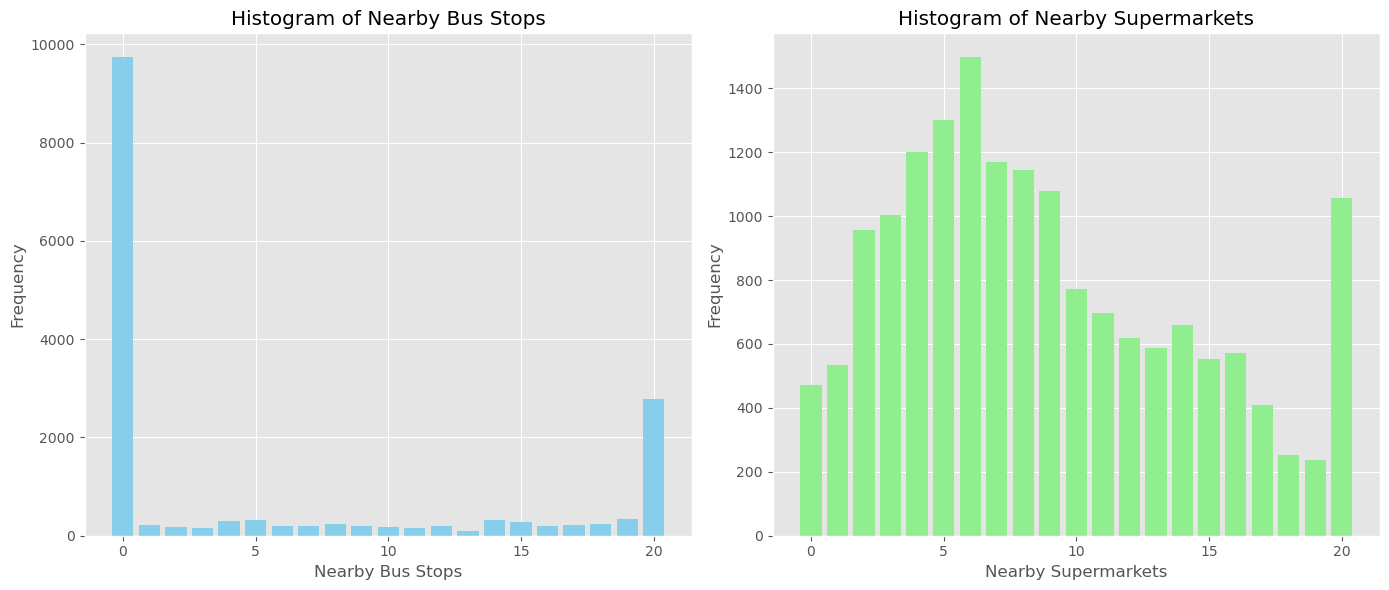

In [79]:
# Check distributions

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Histogram for nearby_bus_stops
axes[0].bar(df['nearby_bus_stops'].value_counts().index, 
            df['nearby_bus_stops'].value_counts().values, 
            color='skyblue')
axes[0].set_title('Histogram of Nearby Bus Stops')
axes[0].set_xlabel('Nearby Bus Stops')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis ='x', rotation = 0)

# Histogram for nearby_supermarkets
axes[1].bar(df['nearby_supermarkets'].value_counts().index, 
            df['nearby_supermarkets'].value_counts().values, 
            color='lightgreen')
axes[1].set_title('Histogram of Nearby Supermarkets')
axes[1].set_xlabel('Nearby Supermarkets')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis ='x', rotation = 0)

plt.tight_layout()
plt.show()

In [239]:
# Check number of unique values of each column
# `nearby_station_distance` and `facilities` consist of lists which lead to error for using `nunique()`
# Thus, we omit for a while

col = [x for x in df.columns.tolist() if x != 'nearby_station_distance' and x != 'facilities']
df.groupby(['property_type', 'is_train'])[col].nunique().T

# According to the results, both `subdistrict` and `address` have a large number of unique values. 
# Since these are categorical variables, it makes sense to ignore both columns. 
# Although `district` also has many unique values, it is clear that it plays a significant role in the decision to buy a property. 
# Therefore, we will retain the `district` column and explore ways to utilize it effectively.

property_type            Condo       Detached House       Townhouse      
is_train                     0     1              0     1         0     1
id                        1637  9206            347  2169       516  2896
province                     3     3              3     3         3     3
district                    47    50             39    52        45    52
subdistrict                130   162            105   163       121   162
address                    705  1174            245   768       317   978
property_type                1     1              1     1         1     1
total_units                550   735             78   229        94   232
bedrooms                     3     6              7    10         7    10
baths                        4     6              5    10         6     8
floor_area                  75   110            127   276       132   236
floor_level                 43    51              3     8         4     6
land_area                    0     0             70   141        40    82
latitude                   776  1324            285  1251       421  1738
longitude                  774  1322            279  1233       412  1721
nearby_stations              4     4              3     4         3     4
nearby_bus_stops            20    20             20    20        20    20
nearby_supermarkets         20    20             17    20        19    20
nearby_shops                20    20             18    20        20    20
year_built                  30    32             17    21        19    21
month_built                 12    12              5     4         4     6
price                        0   946              0   295         0   347
is_train                     1     1              1     1         1     1
minimum_station_distance    98   101             17    56        33    75
has_security                 2     2              2     2         2     2
has_pool                     2     2              2     2         2     2
has_sports                   2     2              2     2         2     2
has_parking                  2     2              2     2         2     2

In [240]:
# Check percentage of NaN values for each column

df.groupby(['property_type','is_train']).agg(lambda group: (group.isnull().mean() * 100).round(2)).T

# According to the results, `total_units` has a large percentage of NaN.
# If we fill these NaN values with a specific number, that number will take over the entire column, making the imputation pointless.
# Additionally, filling them in one-by-one is challenging due to the high percentage of NaN values.

# In case  of `month_built` which also has a large percentage of NaN.
# Since we can use `year_built` instead, we ignore this column too.

property_type              Condo         Detached House        Townhouse       
is_train                       0       1              0      1         0      1
id                          0.00    0.00           0.00   0.00      0.00   0.00
province                    0.00    0.00           0.00   0.00      0.00   0.00
district                    0.00    0.00           0.00   0.00      0.00   0.00
subdistrict                 0.18    0.12           0.00   0.00      0.00   0.00
address                     0.00    0.00           0.00   0.00      0.00   0.00
total_units                 1.89    1.88          67.44  65.51     73.06  74.86
bedrooms                    0.37    0.23           0.58   0.51      0.39   0.38
baths                       0.43    0.21           0.58   0.37      0.19   0.28
floor_area                  0.00    0.00           0.00   0.00      0.00   0.00
floor_level                21.69   20.18          87.61  85.06     85.27  85.46
land_area                 100.00  100.00           3.17   2.54      2.13   3.21
latitude                    0.00    0.00           0.00   0.00      0.00   0.00
longitude                   0.00    0.00           0.00   0.00      0.00   0.00
nearby_stations             0.00    0.00           0.00   0.00      0.00   0.00
nearby_station_distance    26.70   26.48          93.37  93.68     89.34  88.85
nearby_bus_stops           65.24   64.64          46.40  45.78     47.48  45.51
nearby_supermarkets         1.16    0.56          10.09   9.04      6.20   4.77
nearby_shops                0.00    0.00           0.00   0.00      0.00   0.00
year_built                  0.00    0.00           0.00   0.00      0.00   0.00
month_built                 9.16    9.66          97.98  97.28     99.22  99.27
facilities                  0.00    0.00           0.00   0.00      0.00   0.00
price                     100.00    0.00         100.00   0.00    100.00   0.00
minimum_station_distance    0.00    0.00           0.00   0.00      0.00   0.00
has_security                0.00    0.00           0.00   0.00      0.00   0.00
has_pool                    0.00    0.00           0.00   0.00      0.00   0.00
has_sports                  0.00    0.00           0.00   0.00      0.00   0.00
has_parking                 0.00    0.00           0.00   0.00      0.00   0.00

In [241]:
# Drop all columns that we consider to be ignored

df.drop(columns = ['subdistrict', 'address', 'total_units', 'month_built'], inplace = True)

In [244]:
# Recall NaNs
df.groupby(['property_type']).agg(lambda group: (group.isnull().mean() * 100).round(2)).T

property_type,Condo,Detached House,Townhouse
id,0.00,0.00,0.00
province,0.00,0.00,0.00
district,0.00,0.00,0.00
bedrooms,0.25,0.52,0.38
baths,0.24,0.40,0.26
floor_area,0.00,0.00,0.00
floor_level,20.41,85.41,85.43
land_area,100.00,2.62,3.05
latitude,0.00,0.00,0.00
longitude,0.00,0.00,0.00


In [245]:
# Check columns having zeros
(df == 0).sum()

id                             0
province                       0
district                       0
property_type                  0
bedrooms                       0
baths                         23
floor_area                     0
floor_level                    0
land_area                      0
latitude                       0
longitude                      0
nearby_stations             8265
nearby_station_distance        0
nearby_bus_stops               0
nearby_supermarkets            0
nearby_shops                   0
year_built                  4914
facilities                     0
price                          0
is_train                    2500
minimum_station_distance    8265
has_security                2986
has_pool                    4810
has_sports                  5167
has_parking                 5414
dtype: int64

In [247]:
# Check statistics

df.groupby(['property_type','is_train'])[['bedrooms']].describe().T

# Since the number of bedrooms should be an integer and the data exhibits low dispersion, 
# we will impute the NaN values with the median number of bedrooms for each `property_type`

property_type         Condo              Detached House                Townhouse             
is_train                  0            1              0            1           0            1
bedrooms count  1631.000000  9185.000000     345.000000  2158.000000  514.000000  2885.000000
         mean      1.174126     1.188568       3.336232     3.341520    2.988327     2.991681
         std       0.387336     0.409677       0.768185     0.780291    0.751775     0.737776
         min       1.000000     1.000000       1.000000     1.000000    1.000000     1.000000
         25%       1.000000     1.000000       3.000000     3.000000    3.000000     3.000000
         50%       1.000000     1.000000       3.000000     3.000000    3.000000     3.000000
         75%       1.000000     1.000000       4.000000     4.000000    3.000000     3.000000
         max       3.000000     8.000000      10.000000    10.000000    7.000000    10.000000

In [248]:
# Assign the median of bedrooms for each `property_type`

property_types = ['Condo', 'Detached House', 'Townhouse']

for property_type in property_types:
    median_bedrooms = df.loc[df['property_type'] == property_type, 'bedrooms'].median()
    df.loc[(df['property_type'] == property_type) & (df['bedrooms'].isnull()), 'bedrooms'] = median_bedrooms

# This is equivalent to a single line of code
# df['bedrooms'] = df.groupby('property_type')['bedrooms'].transform(lambda x: x.fillna(x.median()))

In [249]:
# Recheck
df['bedrooms'].isnull().sum()

0

In [251]:
# Check statistics

df.groupby(['property_type','is_train'])[['baths']].describe().T

property_type        Condo              Detached House                Townhouse             
is_train                 0            1              0            1           0            1
baths count    1630.000000  9187.000000     345.000000  2161.000000  515.000000  2888.000000
      mean        1.100613     1.109938       2.675362     2.684405    2.466019     2.437673
      std         0.308961     0.330430       0.693912     0.806445    0.771773     0.760285
      min         0.000000     0.000000       1.000000     0.000000    1.000000     0.000000
      25%         1.000000     1.000000       2.000000     2.000000    2.000000     2.000000
      50%         1.000000     1.000000       3.000000     3.000000    2.000000     2.000000
      75%         1.000000     1.000000       3.000000     3.000000    3.000000     3.000000
      max         3.000000     8.000000       5.000000     9.000000    6.000000     7.000000

In [252]:
# We will impute `baths` with the median for the same reasons as we did for `bedrooms`.
# But we also change zeros to the median

for property_type in property_types:
    median_baths = df.loc[df['property_type'] == property_type, 'baths'].median()
    df.loc[(df['property_type'] == property_type) & ((df['baths'].isnull()) | (df['baths'] == 0)), 'baths'] = median_baths

In [253]:
# Recheck NaNs
df['baths'].isnull().sum()

0

In [254]:
# Recheck Zeros

df['baths'].value_counts()

baths
1.0    9845
2.0    4194
3.0    2185
4.0     431
5.0      90
6.0      19
8.0       3
7.0       3
9.0       1
Name: count, dtype: int64

### Export

In [265]:
# train
train_clean = df[(df['is_train'] == 1)]
train_clean.to_csv('../data/train_clean.csv', index = False)

# test
test_clean = df[(df['is_train'] == 0)]
test_clean.to_csv('../data/test_clean.csv', index = False)